# **Latin Morphological Analyser** - Confidence Thresholds

This notebook analyses prediction confidence on the test set, produces calibration / reliability diagrams and accuracy-coverage trade-off curves, and demonstrates thresholded inference with fallback flags.

## **Set Up Environment**

In [1]:
import os

### Install Latin BERT

Download the pre-trained Latin BERT model from the GitHub repository and define the path for the model to be used for fine-tuning.

In [2]:
# clone latin bert repo
!git clone https://github.com/dbamman/latin-bert.git
%cd latin-bert

Cloning into 'latin-bert'...
remote: Enumerating objects: 154, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 154 (delta 4), reused 27 (delta 3), pack-reused 122 (from 1)
Receiving objects: 100% (154/154), 6.77 MiB | 4.14 MiB/s, done.
Resolving deltas: 100% (59/59), done.
/content/latin-bert


In [3]:
# Download pre-trained BERT model for Latin
!./scripts/download.sh

--2026-05-02 00:45:05--  https://drive.usercontent.google.com/download?export=download&id=1Te_14UB-DZ8wYPhHGyDg7LadDTjNzpti&confirm=t&uuid=aa4db889-3533-4382-a9ab-de8c47331e04
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.130.132, 2404:6800:4003:c01::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.130.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 448020480 (427M) [application/octet-stream]
Saving to: ‘latin_bert.tar’

latin_bert.tar      100%[===================>] 427.27M  32.5MB/s    in 15s     

2026-05-02 00:45:21 (29.2 MB/s) - ‘latin_bert.tar’ saved [448020480/448020480]



In [4]:
!ls -lah models/latin_bert | head

total 428M
drwxrwxr-x 2 1001 1001 4.0K Sep  4  2020 .
drwxr-xr-x 4 root root 4.0K May  2 00:45 ..
-rw-rw-r-- 1 1001 1001  503 Sep  4  2020 config.json
-rw-rw-r-- 1 1001 1001 428M Sep  4  2020 pytorch_model.bin
-rw-rw-r-- 1 1001 1001 217K Sep  4  2020 vocab.txt


In [5]:
%cd ..

/content


In [6]:
MODEL_PATH = os.path.join("latin-bert", "models", "latin_bert")

### Import Dependencies

1. Import all required libraries.
2. Mount Google Drive for storage access.
3. Setup HuggingFace access through token.
4. Define available device to be used.

In [7]:
import sys
import json
from collections import defaultdict
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from safetensors.torch import load_file
import transformers
from transformers import AutoTokenizer
import datasets
from datasets import load_from_disk
import sklearn
from sklearn.metrics import classification_report
import matplotlib
import matplotlib.pyplot as plt

In [8]:
%matplotlib inline

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

In [11]:
print(torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

True
Using device: cuda


In [12]:
# Import shared definitions (constants, dataclasses, model classes, data collator)
sys.path.append('/content/drive/MyDrive/FYP')
from morph_constants import FEATURE_ORDER, POS_FEATURE_MASK, ALL_FEATS, IGNORE_INDEX
from morphological_analyser import LatinMorphologicalAnalyserConfig, LatinMorphologicalAnalyser, MultiLabelDataCollator

In [13]:
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("scikit-learn:", sklearn.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

Python: 3.12.13
PyTorch: 2.10.0+cu128
Transformers: 5.0.0
Datasets: 4.0.0
scikit-learn: 1.6.1
NumPy: 2.0.2
Matplotlib: 3.10.0
CUDA: 12.8
GPU: Tesla T4


## **Load Model**

In [14]:
# Load the trained model and tokenizer saved
MODEL_DIR = "/content/drive/MyDrive/FYP/morphological_analyser_multihead"

tokenizer   = AutoTokenizer.from_pretrained(MODEL_DIR)

with open(os.path.join(MODEL_DIR, "config.json")) as f:
    config = json.load(f)

label2id_all = config["label2id_all"]
id2label_all = {
    feat: {int(k): v for k, v in d.items()}
    for feat, d in config["id2label_all"].items()
}
pos_feature_mask = config["pos_feature_mask"]
num_labels_per_feat = config["num_labels_per_feat"]

morph_config = LatinMorphologicalAnalyserConfig(
    bert_model_path    = MODEL_PATH,
    num_labels_per_feat = num_labels_per_feat,
    label2id_all        = label2id_all,
    id2label_all = {feat: {str(k): v for k, v in d.items()} for feat, d in id2label_all.items()}, # convert int keys to str for JSON
    pos_feature_mask    = pos_feature_mask,
    pos_embed_dim      = 64,
    dropout            = 0.1,
)

model_loaded = LatinMorphologicalAnalyser(morph_config).to(device)

# Load manually — bypasses from_pretrained's broken key remapping
state_dict = load_file(
    os.path.join(MODEL_DIR, "model.safetensors"),
    device=device
)
missing, unexpected = model_loaded.load_state_dict(state_dict, strict=False)
model = model_loaded.eval()  # set to inference mode

print("Loaded model from", MODEL_DIR)

You are using a model of type latin_morphological_analyser to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: latin-bert/models/latin_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model from /content/drive/MyDrive/FYP/morphological_analyser_multihead


In [15]:
print(model)

LatinMorphologicalAnalyser(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32900, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

In [16]:
# Rebuild the POS-feature compatibility mask tensor from the loaded vocabularies.
def build_pos_mask_tensor(label2id_pos, device):
    """
    Build a (num_pos, num_features) bool tensor directly from POS_FEATURE_MASK.
    Any POS code not listed in POS_FEATURE_MASK gets all-False (no features).
    Unknown codes are reported so you can add them explicitly.
    """
    num_pos   = len(label2id_pos)
    num_feats = len(FEATURE_ORDER)
    mask      = torch.zeros(num_pos, num_feats, dtype=torch.bool)

    for pos_code, pos_idx in label2id_pos.items():
        if pos_code in POS_FEATURE_MASK:
            for fi, applicable in enumerate(POS_FEATURE_MASK[pos_code]):
                mask[pos_idx, fi] = applicable
        else:
            # Surface any unmapped codes immediately rather than silently
            # treating them as all-False
            print(f"WARNING: POS code '{pos_code}' not in POS_FEATURE_MASK "
                  f"— all features will be masked off for this tag. "
                  f"Add it explicitly.")

    return mask.to(device)


pos_mask_tensor = build_pos_mask_tensor(label2id_all["pos"], device)

## **Load Test Set**

In [17]:
# Load the tokenized test set saved
PROCESSED_DIR = "/content/drive/MyDrive/FYP/processed"
test_ds = load_from_disk(f"{PROCESSED_DIR}/test_ds")
print(f"{len(test_ds)} test examples")

1778 test examples


In [18]:
# Rebuild the data collator (used by `evaluate_all_features` and `collect_predictions_with_confidence`).
data_collator_multi = MultiLabelDataCollator(
    tokenizer  = tokenizer,
    feat_names = ALL_FEATS,
)

## **Finding Thresholds**

In [19]:
# COLLECT PREDICTIONS WITH CONFIDENCE SCORES

# want to know:

# for each prediction the model makes
# -> (a) what was its confidence
# -> (b) was it right?

# (confidence, correct?) pairs

# helps answer questions like; when the model says its 90% confident
# is it actually right 90% of the time

# helps with threshold selections


def collect_predictions_with_confidence(
    model, dataset, tokenizer, device,
    data_collator, id2label_all, pos_mask_tensor,
    feature_order, all_feats, ignore_index=-100,
    batch_size=32
):
    """
    Run inference on the full dataset and collect, for every valid token
    and every applicable feature:
      - the predicted label
      - the true label
      - the confidence (max softmax probability)
      - the full probability distribution (for deeper analysis)

    Returns a dict keyed by feature name, each containing parallel lists.
    """
    model.eval()

    # Storage: one entry per feature
    results = {
        feat: {
            "true_labels": [],
            "pred_labels": [],
            "confidences": [],     # max softmax prob for the predicted class
            "correct": [],         # boolean: was the prediction correct?
            "entropy": [],         # entropy of the distribution (uncertainty)
        }
        for feat in all_feats
    }

    loader = DataLoader(
        dataset.with_format("torch"),
        batch_size=batch_size,
        collate_fn=data_collator,
    )

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        with torch.no_grad():
            output = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
            )

        # ── POS ────────────────────────────────────────────────────────
        pos_logits = output.logits                          # (B, T, num_pos)
        pos_probs = F.softmax(pos_logits, dim=-1)           # (B, T, num_pos)
        pos_conf, pos_pred = pos_probs.max(dim=-1)          # (B, T) each
        true_pos = batch["labels_pos"]                      # (B, T)
        valid = true_pos != ignore_index                    # (B, T)

        # Collect POS results
        if valid.any():
            t = true_pos[valid].cpu()
            p = pos_pred[valid].cpu()
            c = pos_conf[valid].cpu()

            # Entropy: -sum(p * log(p)), measures how "spread out" the distribution is
            pos_ent = -(pos_probs[valid] * (pos_probs[valid] + 1e-10).log()).sum(dim=-1).cpu()

            results["pos"]["true_labels"].extend(t.tolist())
            results["pos"]["pred_labels"].extend(p.tolist())
            results["pos"]["confidences"].extend(c.tolist())
            results["pos"]["correct"].extend((t == p).tolist())
            results["pos"]["entropy"].extend(pos_ent.tolist())

        # ── Feature heads ──────────────────────────────────────────────
        feature_logits = output.feature_logits

        for feat_idx, feat in enumerate(feature_order):
            true_feat = batch[f"labels_{feat}"]             # (B, T)

            # Only evaluate on tokens where this feature is applicable
            pos_clamp = true_pos.clone()
            pos_clamp[~valid] = 0
            applicable = pos_mask_tensor[pos_clamp, feat_idx] & valid

            if not applicable.any():
                continue

            feat_logits_applicable = feature_logits[feat][applicable]   # (N, num_labels)
            feat_probs = F.softmax(feat_logits_applicable, dim=-1)     # (N, num_labels)
            feat_conf, feat_pred = feat_probs.max(dim=-1)              # (N,) each
            feat_true = true_feat[applicable]                          # (N,)

            feat_ent = -(feat_probs * (feat_probs + 1e-10).log()).sum(dim=-1)

            results[feat]["true_labels"].extend(feat_true.cpu().tolist())
            results[feat]["pred_labels"].extend(feat_pred.cpu().tolist())
            results[feat]["confidences"].extend(feat_conf.cpu().tolist())
            results[feat]["correct"].extend((feat_true.cpu() == feat_pred.cpu()).tolist())
            results[feat]["entropy"].extend(feat_ent.cpu().tolist())

    # Convert to numpy for easier analysis
    for feat in results:
        for key in results[feat]:
            results[feat][key] = np.array(results[feat][key])

    return results



In [20]:
# RUN COLLECTION ON TEST SET

prediction_data = collect_predictions_with_confidence(
    model=model,
    dataset=test_ds,
    tokenizer=tokenizer,
    device=device,
    data_collator=data_collator_multi,
    id2label_all=id2label_all,
    pos_mask_tensor=pos_mask_tensor,
    feature_order=FEATURE_ORDER,
    all_feats=ALL_FEATS,
    ignore_index=IGNORE_INDEX,
    batch_size=32,
)


In [21]:
# PRINT OVERVIEW STATISTICS

# For each feature:
# - Total predictions: how many tokens had this feature applicable
# - Overall accuracy: how often the model was correct (no threshold)
# - Mean confidence: average max-probability across all predictions
# - Mean confidence when CORRECT vs WRONG



def print_overview(prediction_data, id2label_all, all_feats):
    print(f"{'Feature':<12} {'N':>8} {'Accuracy':>10} {'Mean Conf':>10} "
          f"{'Conf|Correct':>13} {'Conf|Wrong':>11} {'Separation':>11}")
    print("─" * 80)

    for feat in all_feats:
        data = prediction_data[feat]
        if len(data["correct"]) == 0:
            continue

        n = len(data["correct"])
        acc = data["correct"].mean()
        mean_conf = data["confidences"].mean()

        correct_mask = data["correct"].astype(bool)
        wrong_mask = ~correct_mask

        conf_correct = data["confidences"][correct_mask].mean() if correct_mask.any() else 0
        conf_wrong = data["confidences"][wrong_mask].mean() if wrong_mask.any() else 0
        separation = conf_correct - conf_wrong

        print(f"{feat:<12} {n:>8,} {acc:>10.4f} {mean_conf:>10.4f} "
              f"{conf_correct:>13.4f} {conf_wrong:>11.4f} {separation:>11.4f}")




print_overview(prediction_data, id2label_all, ALL_FEATS)


Feature             N   Accuracy  Mean Conf  Conf|Correct  Conf|Wrong  Separation
────────────────────────────────────────────────────────────────────────────────
pos            16,423     0.7561     0.7633        0.8527      0.4861      0.3667
person          4,073     0.7690     0.8111        0.8716      0.6095      0.2622
number         11,542     0.7827     0.7971        0.8409      0.6392      0.2017
tense           4,073     0.7022     0.7219        0.7900      0.5613      0.2286
mood            4,073     0.7999     0.8325        0.8787      0.6479      0.2308
voice           4,073     0.9065     0.9000        0.9096      0.8073      0.1023
gender          7,469     0.7052     0.7218        0.7936      0.5502      0.2434
case            7,469     0.7455     0.7740        0.8464      0.5619      0.2845
degree          2,143     0.8791     0.8880        0.9184      0.6672      0.2512


In [22]:
# https://medium.com/data-science/introduction-to-reliability-diagrams-for-probability-calibration-ed785b3f5d44
# https://github.com/hollance/reliability-diagrams

# When a model is calibrated, the confidence score should equal the accuracy

# reliability diagram:
# perfectly calibraed model -> diagonal line  (confidence equals accuracye)

# if the model is overcondfident (conf > accuracy) then the threhsold needs
# to be set higher

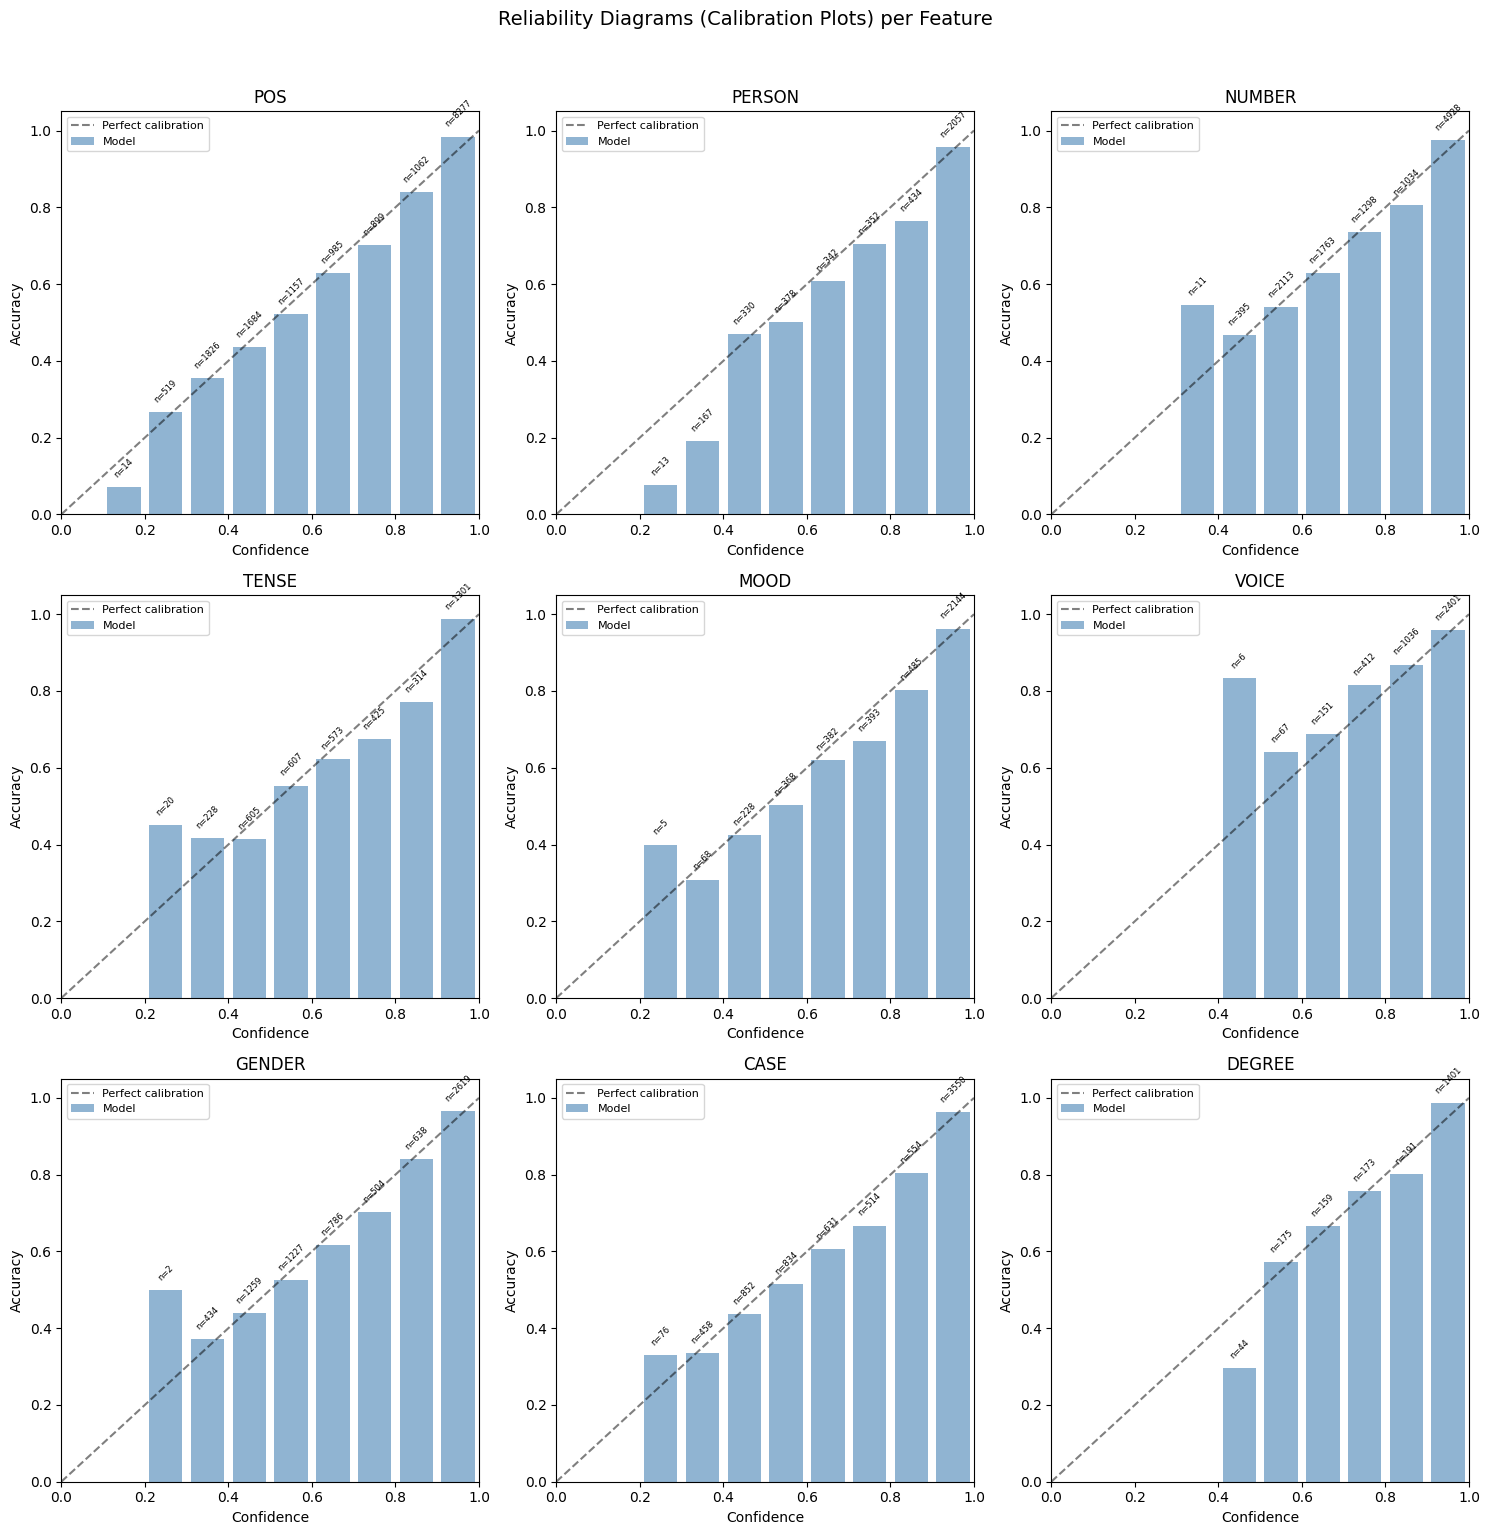

In [23]:
# reliabiity diagrams

def plot_reliability_diagrams(prediction_data, all_feats, n_bins=10):
    feats_with_data = [f for f in all_feats if len(prediction_data[f]["correct"]) > 0]
    n = len(feats_with_data)
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for idx, feat in enumerate(feats_with_data):
        ax = axes[idx]
        data = prediction_data[feat]
        confs = data["confidences"]
        correct = data["correct"].astype(float)

        bin_edges = np.linspace(0, 1, n_bins + 1)
        bin_accs = []
        bin_confs = []
        bin_counts = []

        for i in range(n_bins):
            mask = (confs >= bin_edges[i]) & (confs < bin_edges[i + 1])
            if i == n_bins - 1:  # include right edge for last bin
                mask = (confs >= bin_edges[i]) & (confs <= bin_edges[i + 1])
            if mask.sum() > 0:
                bin_accs.append(correct[mask].mean())
                bin_confs.append(confs[mask].mean())
                bin_counts.append(mask.sum())
            else:
                bin_accs.append(0)
                bin_confs.append((bin_edges[i] + bin_edges[i + 1]) / 2)
                bin_counts.append(0)

        bin_centers = [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(n_bins)]

        # Plot calibration
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
        ax.bar(bin_centers, bin_accs, width=1/n_bins * 0.8, alpha=0.6, color='steelblue', label='Model')
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{feat.upper()}')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)

        # Add count annotations
        for i, count in enumerate(bin_counts):
            if count > 0:
                ax.text(bin_centers[i], bin_accs[i] + 0.02, f'n={count}',
                        ha='center', va='bottom', fontsize=6, rotation=45)

    # Hide unused subplots
    for idx in range(len(feats_with_data), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle('Reliability Diagrams (Calibration Plots) per Feature', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()



plot_reliability_diagrams(prediction_data, ALL_FEATS)

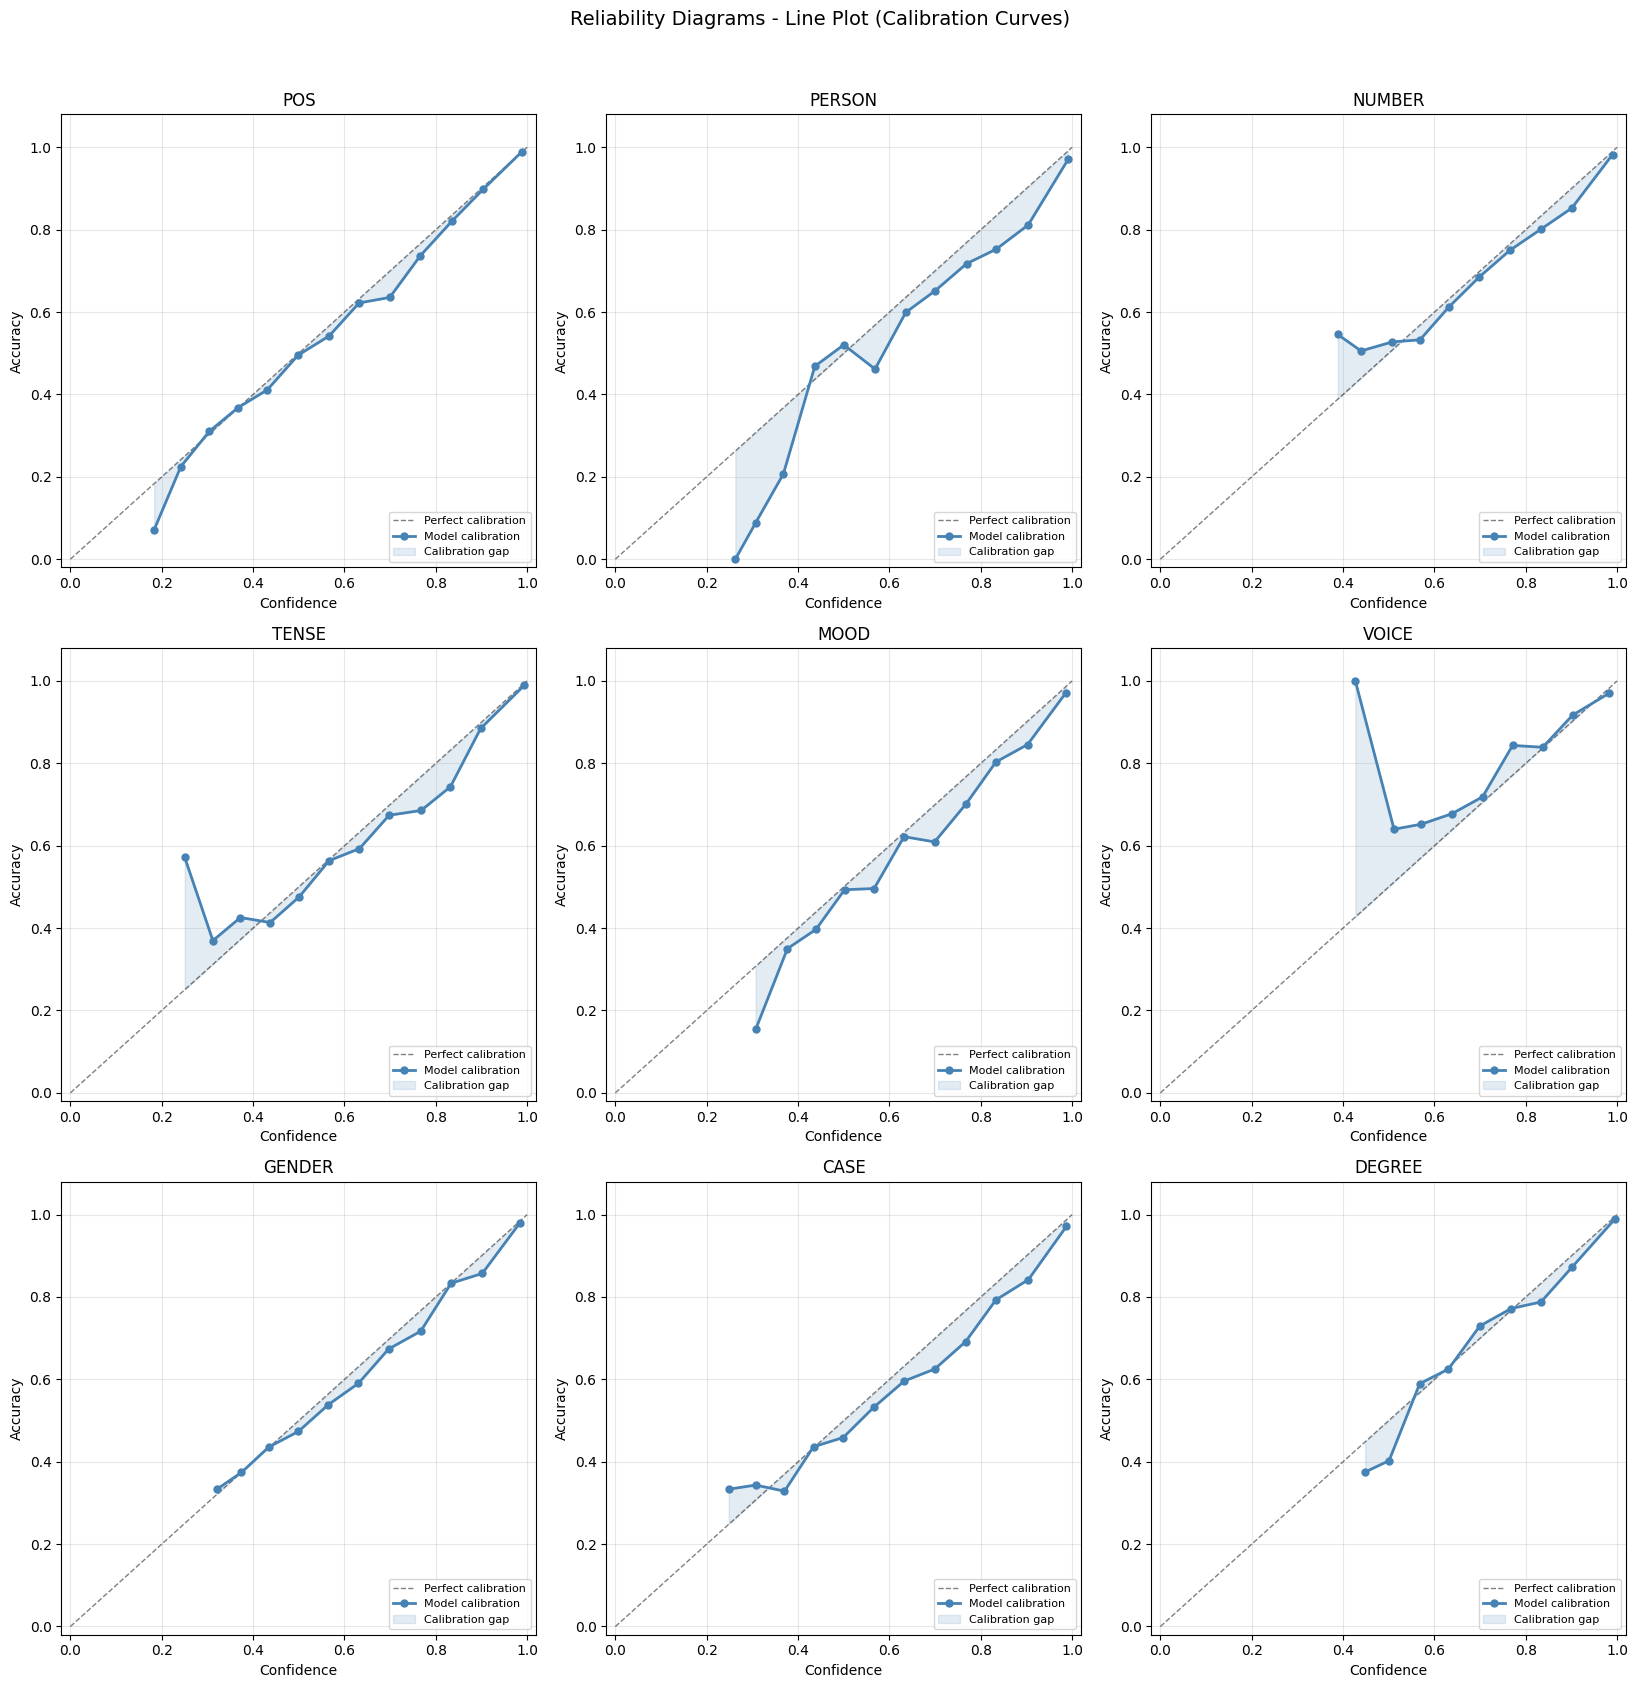

In [24]:
# reliabiltiy diagram but line instead of bars

# If the blue line is BELOW the diagonal, the model is OVERCONFIDENT
# eg the model is 90 percent confident but it is actually right only 80% of the time

# If the blue line is ABOVE the diagonal, the model is UNDERCONFIDENT
# eg its 70% sure but is actually right 85% of the time


def plot_reliability_diagrams_line(prediction_data, all_feats, n_bins=15):
    """
    Line/curve version of reliability diagrams.
    Shows calibration curves with gap shading and sample count bars.
    """
    feats_with_data = [f for f in all_feats if len(prediction_data[f]["correct"]) > 0]
    n = len(feats_with_data)
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 5.5 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for idx, feat in enumerate(feats_with_data):
        ax = axes[idx]
        data = prediction_data[feat]
        confs = data["confidences"]
        correct = data["correct"].astype(float)
        total_samples = len(confs)

        bin_edges = np.linspace(0, 1, n_bins + 1)
        bin_centers = []
        bin_accs = []
        bin_mean_confs = []
        bin_counts = []

        for i in range(n_bins):
            if i < n_bins - 1:
                mask = (confs >= bin_edges[i]) & (confs < bin_edges[i + 1])
            else:
                mask = (confs >= bin_edges[i]) & (confs <= bin_edges[i + 1])

            count = mask.sum()
            center = (bin_edges[i] + bin_edges[i + 1]) / 2

            if count > 0:
                bin_centers.append(center)
                bin_accs.append(correct[mask].mean())
                bin_mean_confs.append(confs[mask].mean())
                bin_counts.append(count)
            else:
                bin_centers.append(center)
                bin_accs.append(np.nan)
                bin_mean_confs.append(center)
                bin_counts.append(0)

        bin_centers = np.array(bin_centers)
        bin_accs = np.array(bin_accs)
        bin_mean_confs = np.array(bin_mean_confs)
        bin_counts = np.array(bin_counts)

        # Only plot bins that have data
        valid_mask = ~np.isnan(bin_accs)

        # ── Calibration curve ──────────────────────────────────────────
        # Perfect calibration diagonal
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1, label='Perfect calibration')

        # Model's calibration curve (using mean confidence per bin on x-axis
        # rather than bin center — this is more accurate because bins may
        # not be uniformly filled)
        if valid_mask.any():
            x_vals = bin_mean_confs[valid_mask]
            y_vals = bin_accs[valid_mask]

            ax.plot(x_vals, y_vals, 'o-', color='steelblue', linewidth=2,
                    markersize=5, label='Model calibration', zorder=3)

            # Shade the gap between model and perfect calibration
            ax.fill_between(x_vals, x_vals, y_vals, alpha=0.15, color='steelblue',
                            label='Calibration gap')


        # # ── ECE (Expected Calibration Error) ──────────────────────────
        # # ECE = sum over bins of (count_in_bin / total) * |accuracy - confidence|
        # ece = 0.0
        # for i in range(len(bin_centers)):
        #     if bin_counts[i] > 0 and not np.isnan(bin_accs[i]):
        #         ece += (bin_counts[i] / total_samples) * abs(bin_accs[i] - bin_mean_confs[i])

        # ax.text(0.05, 0.92, f'ECE = {ece:.4f}', transform=ax.transAxes,
        #         fontsize=10, verticalalignment='top',
        #         bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7))

        # ── Labels and formatting ─────────────────────────────────────
        ax.set_xlabel('Confidence', fontsize=10)
        ax.set_ylabel('Accuracy', fontsize=10)
        ax.set_title(f'{feat.upper()}', fontsize=12)
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.08)
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(True, alpha=0.3)

    for idx in range(len(feats_with_data), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle('Reliability Diagrams - Line Plot (Calibration Curves)',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_reliability_diagrams_line(prediction_data, ALL_FEATS, n_bins=15)

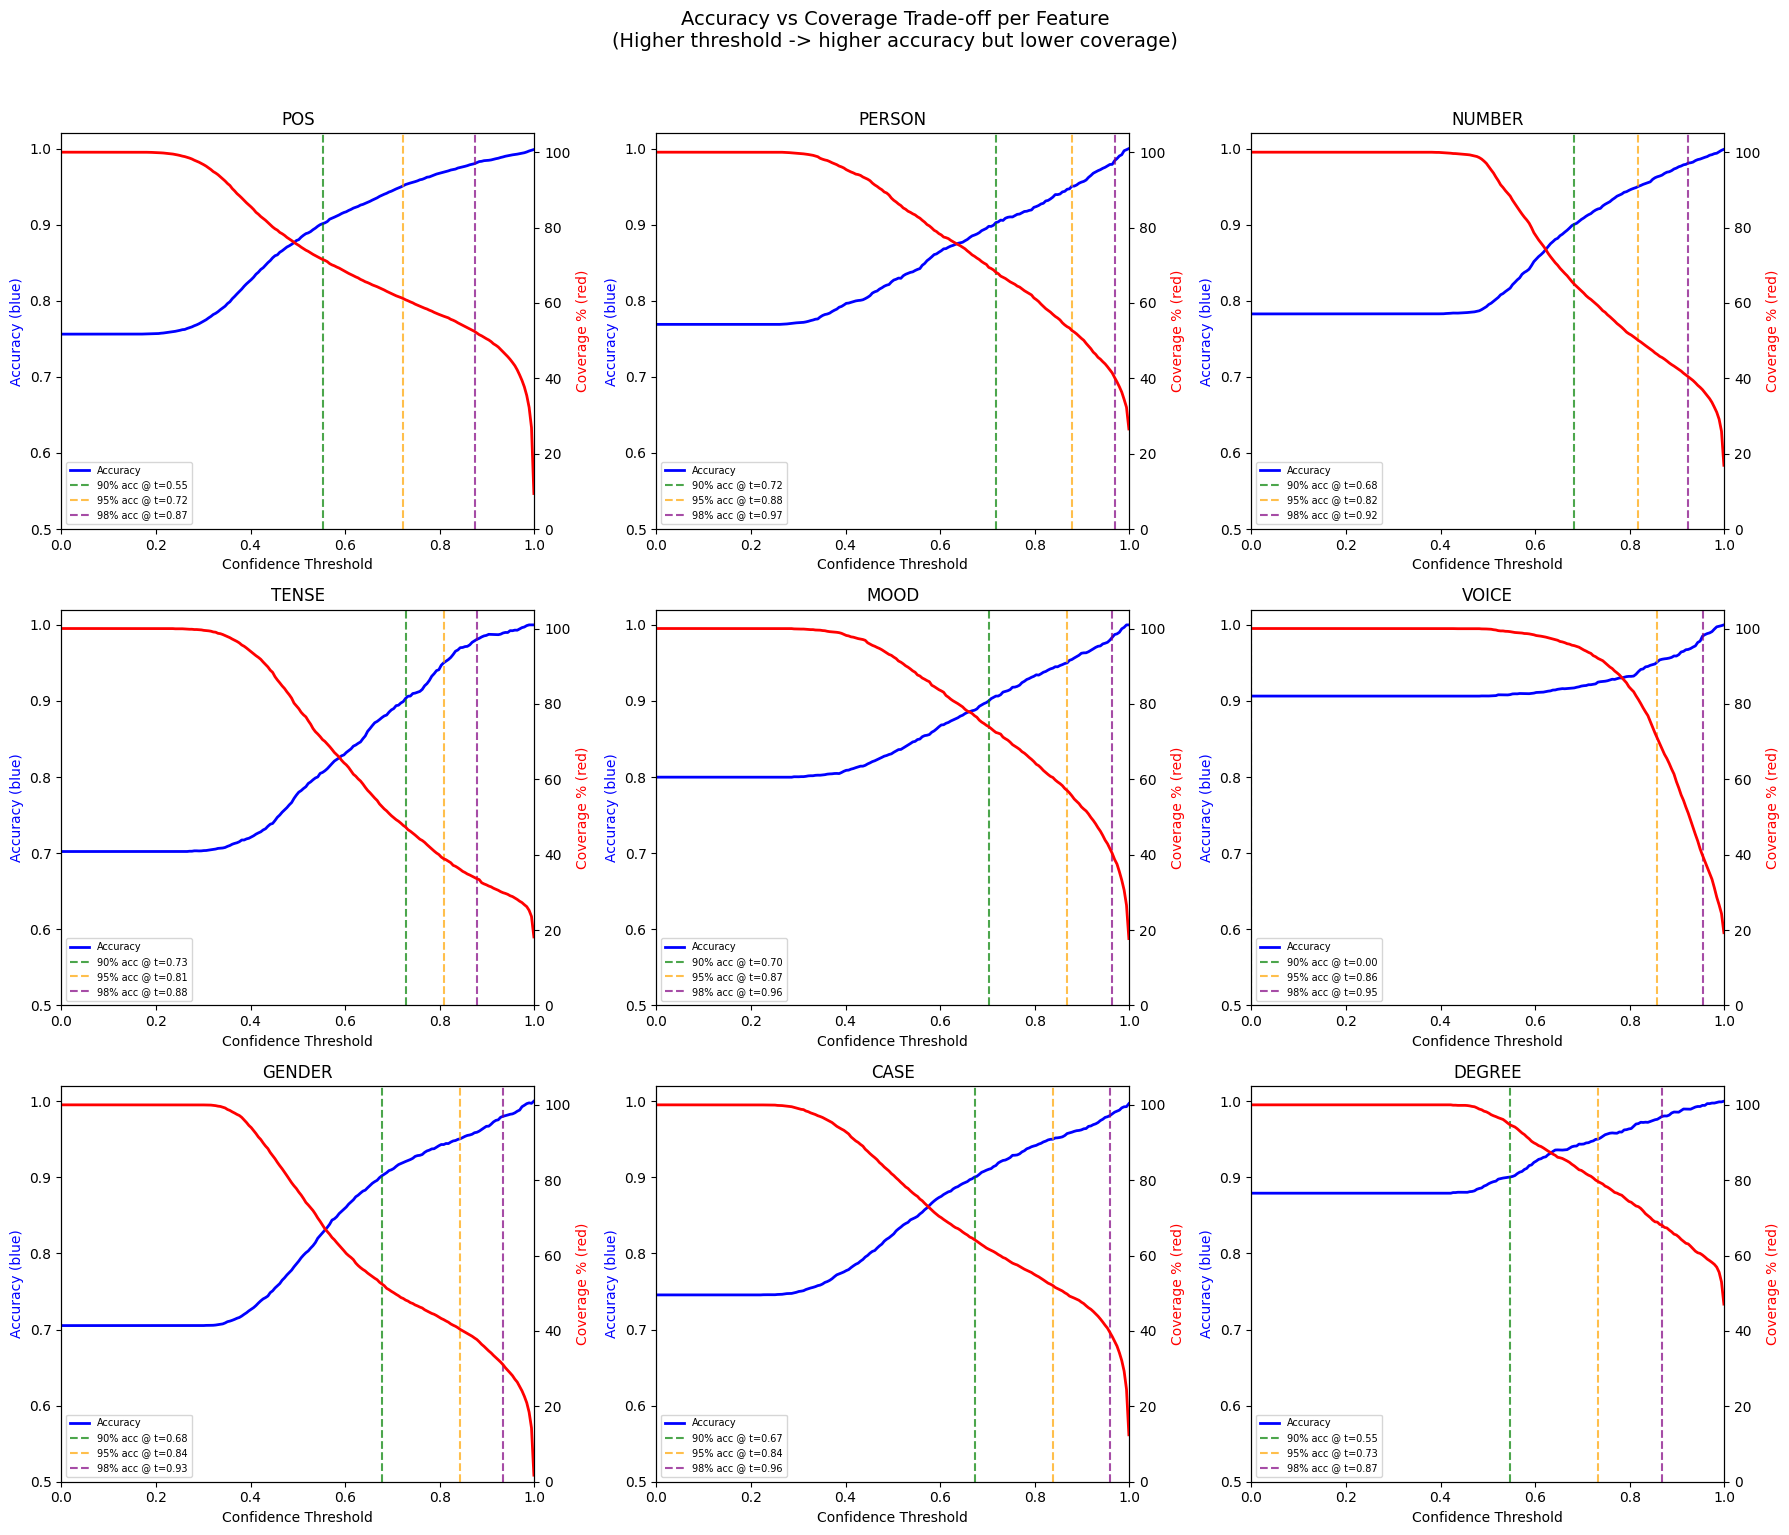

In [25]:
# accuracy vs coverage tradeoff curbves

# accuracy vs coverage tradeoff
# raising the confidence threhsold
# -> accuracy increases because u only keep predictions the model is sure about
# -> coverage decreases because more predictions use fallback emthod

# want to find where acc is high enoguh where u trust the models output
# and wher coverage is high enough that its not falling back for every word

# x-acis: confidence threshold (predictions below this -> fallback)
# Left Y-axis (blue): accuracy of predictions ABOVE the threshold
# Right Y-axis (red): percentage of predictions that meet the threshold (coverage)
# vertical dashed lines show suggested thresholds at specific accuracy targets

# example, if at threshold=0.85:
# - Accuracy = 98% and Coverage = 70%
# -> The model handles 70% of tokens with 98% accuracy
# -> The remaining 30% go to fallback


def plot_accuracy_coverage_tradeoff(prediction_data, all_feats, accuracy_targets=(0.90, 0.95, 0.98)):
    feats_with_data = [f for f in all_feats if len(prediction_data[f]["correct"]) > 0]
    n = len(feats_with_data)
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    threshold_results = {}

    for idx, feat in enumerate(feats_with_data):
        ax = axes[idx]
        data = prediction_data[feat]
        confs = data["confidences"]
        correct = data["correct"].astype(float)

        thresholds = np.linspace(0.0, 0.999, 200)
        accuracies = []
        coverages = []

        for t in thresholds:
            mask = confs >= t
            if mask.sum() > 0:
                accuracies.append(correct[mask].mean())
                coverages.append(mask.mean())
            else:
                accuracies.append(1.0)
                coverages.append(0.0)

        accuracies = np.array(accuracies)
        coverages = np.array(coverages)

        # Plot
        ax.plot(thresholds, accuracies, 'b-', linewidth=2, label='Accuracy')
        ax2 = ax.twinx()
        ax2.plot(thresholds, coverages * 100, 'r-', linewidth=2, label='Coverage %')

        # Find thresholds for accuracy targets
        feat_thresholds = {}
        colors = ['green', 'orange', 'purple']
        for ti, target in enumerate(accuracy_targets):
            # Find lowest threshold where accuracy >= target
            candidates = np.where(accuracies >= target)[0]
            if len(candidates) > 0:
                best_idx = candidates[0]  # lowest threshold achieving target
                feat_thresholds[target] = {
                    "threshold": thresholds[best_idx],
                    "accuracy": accuracies[best_idx],
                    "coverage": coverages[best_idx],
                }
                ax.axvline(x=thresholds[best_idx], color=colors[ti], linestyle='--',
                          alpha=0.7, label=f'{target:.0%} acc @ t={thresholds[best_idx]:.2f}')

        threshold_results[feat] = feat_thresholds

        ax.set_xlabel('Confidence Threshold')
        ax.set_ylabel('Accuracy (blue)', color='b')
        ax2.set_ylabel('Coverage % (red)', color='r')
        ax.set_title(f'{feat.upper()}')
        ax.set_xlim(0, 1)
        ax.set_ylim(0.5, 1.02)
        ax2.set_ylim(0, 105)
        ax.legend(fontsize=7, loc='lower left')

    for idx in range(len(feats_with_data), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle('Accuracy vs Coverage Trade-off per Feature\n'
                 '(Higher threshold -> higher accuracy but lower coverage)',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    return threshold_results



threshold_results = plot_accuracy_coverage_tradeoff(prediction_data, ALL_FEATS)


In [26]:
# RECOMMENDED THRESHOLDS TABLE

# For each feature and accuracy target
# -> What confidence threshold to use
# -> What accuracy you actually achieve
# -> What percentage of tokens the model will handle (coveage)

# different threshold s for different features
# -> per features thresholds

# threshold on the pos first, then if pos passes
# therehsold on each feature


def print_threshold_table(threshold_results, accuracy_targets=(0.90, 0.95, 0.98)):
    print(f"\n")
    print(f"RECOMMENDED THRESHOLDS")

    for target in accuracy_targets:
        print(f"\n{'─'*90}")
        print(f"  Target Accuracy: {target:.0%}")
        print(f"{'─'*90}")
        print(f"  {'Feature':<12} {'Threshold':>10} {'Actual Acc':>12} {'Coverage':>10} {'Fallback %':>12}")
        print(f"  {'─'*58}")

        for feat, thresholds in threshold_results.items():
            if target in thresholds:
                t = thresholds[target]
                print(f"  {feat:<12} {t['threshold']:>10.3f} {t['accuracy']:>12.4f} "
                      f"{t['coverage']:>10.2%} {1 - t['coverage']:>12.2%}")
            else:
                print(f"  {feat:<12} {'N/A':>10} {'—':>12} {'—':>10} {'—':>12}")


print_threshold_table(threshold_results)



RECOMMENDED THRESHOLDS

──────────────────────────────────────────────────────────────────────────────────────────
  Target Accuracy: 90%
──────────────────────────────────────────────────────────────────────────────────────────
  Feature       Threshold   Actual Acc   Coverage   Fallback %
  ──────────────────────────────────────────────────────────
  pos               0.552       0.9013     71.55%       28.45%
  person            0.718       0.9027     68.13%       31.87%
  number            0.683       0.9005     64.98%       35.02%
  tense             0.728       0.9035     47.31%       52.69%
  mood              0.703       0.9001     73.95%       26.05%
  voice             0.000       0.9065    100.00%        0.00%
  gender            0.678       0.9020     52.47%       47.53%
  case              0.673       0.9003     64.21%       35.79%
  degree            0.547       0.9004     94.68%        5.32%

─────────────────────────────────────────────────────────────────────────────

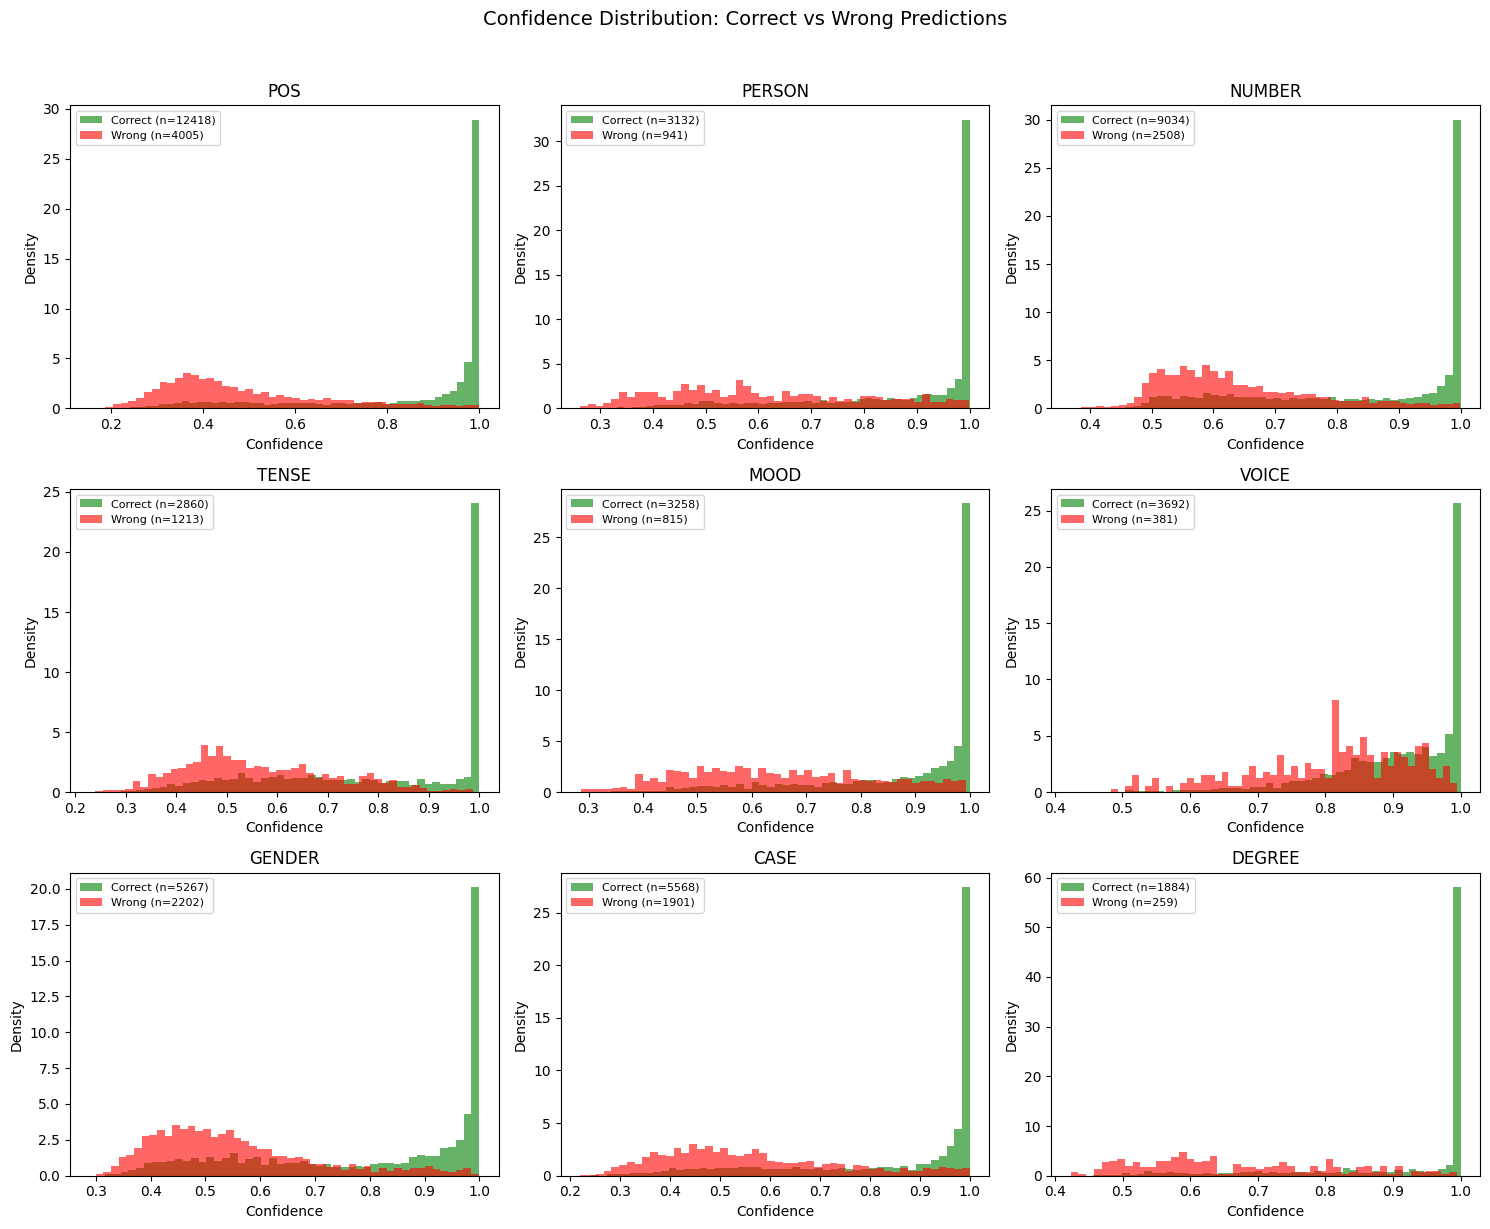

In [27]:
# confidence distribution plot - correct vs wrong

# shows the distribution of confidence values split
# by whetehr the prediction was corect or wrong

# if the 2 distributsions are well separated
# ie correct predictions -> high conf and wrong -> low conf
# confidence based threhsolding is good and will work very well

# if they overlap a lot then the model is overcinfudent
# very confident but giving wrong predicitons


def plot_confidence_distributions(prediction_data, all_feats):
    feats_with_data = [f for f in all_feats
                       if len(prediction_data[f]["correct"]) > 0
                       and (~prediction_data[f]["correct"].astype(bool)).any()]
    n = len(feats_with_data)
    if n == 0:
        print("No features with both correct and wrong predictions to plot.")
        return

    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for idx, feat in enumerate(feats_with_data):
        ax = axes[idx]
        data = prediction_data[feat]
        correct_mask = data["correct"].astype(bool)

        confs_correct = data["confidences"][correct_mask]
        confs_wrong = data["confidences"][~correct_mask]

        ax.hist(confs_correct, bins=50, alpha=0.6, color='green', label=f'Correct (n={len(confs_correct)})', density=True)
        ax.hist(confs_wrong, bins=50, alpha=0.6, color='red', label=f'Wrong (n={len(confs_wrong)})', density=True)
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Density')
        ax.set_title(f'{feat.upper()}')
        ax.legend(fontsize=8)

    for idx in range(len(feats_with_data), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle('Confidence Distribution: Correct vs Wrong Predictions', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_confidence_distributions(prediction_data, ALL_FEATS)

In [28]:

# Step 1: Run model on the word

# Step 2: Check POS confidence
# - If POS confidence < pos_threshold -> fall back ENTIRELY
#   (because if POS is wrong, all downstream features are unreliable)
# - If POS confidence >= pos_threshold -> accept POS, proceed to features

# Step 3: For each morphological feature:
# - If feature confidence < feat_threshold -> fall back for THIS feature only
# - If feature confidence >= feat_threshold -> accept prediction

def predict_with_confidence(
    sentence_words, model, tokenizer, device,
    id2label_all, pos_mask_tensor, feature_order,
    thresholds=None,
):
    """
    Predict morphological features with confidence scores and fallback flags.

    Args:
        sentence_words: list of word strings
        model, tokenizer, device: as usual
        id2label_all: label vocabularies
        pos_mask_tensor: POS-feature compatibility mask
        feature_order: list of feature names
        thresholds: dict[feat] -> float threshold, or single float for all.
                    If None, no thresholding (all predictions accepted).

    Returns:
        list of dicts, one per word. Each dict contains:
          - "word": the input word
          - "pos": {"label": str, "confidence": float, "needs_fallback": bool}
          - "person": {"label": str, "confidence": float, "needs_fallback": bool}
          - ... (for each applicable feature)
          - features not applicable for the predicted POS get:
            {"label": "—", "confidence": None, "needs_fallback": False, "applicable": False}
    """
    model.eval()
    words_lower = [w.lower() for w in sentence_words]

    encoding = tokenizer(
        words_lower,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        max_length=128,
    ).to(device)

    word_ids = encoding.word_ids(batch_index=0)

    with torch.no_grad():
        output = model(**encoding)

    pos_logits = output.logits[0]               # (seq_len, num_pos)
    feature_logits = output.feature_logits


    pos_probs = F.softmax(pos_logits, dim=-1)
    pos_conf, pos_pred = pos_probs.max(dim=-1)

    # Determine thresholds
    if thresholds is None:
        thresholds = {}
    elif isinstance(thresholds, (int, float)):
        t = float(thresholds)
        thresholds = {feat: t for feat in ["pos"] + feature_order}

    results = []
    seen = set()

    for token_idx, word_id in enumerate(word_ids):
        if word_id is None or word_id in seen:
            continue
        seen.add(word_id)

        pos_idx = pos_pred[token_idx].item()
        pos_confidence = pos_conf[token_idx].item()
        pos_str = id2label_all["pos"][pos_idx]
        pos_threshold = thresholds.get("pos", 0.0)

        result = {
            "word": sentence_words[word_id],
            "pos": {
                "label": pos_str,
                "confidence": round(pos_confidence, 4),
                "needs_fallback": pos_confidence < pos_threshold,
                "probabilities": {id2label_all["pos"][i]: round(p, 4)
                                  for i, p in enumerate(pos_probs[token_idx].cpu().tolist())
                                  if p > 0.01},  # only show probs > 1%
            },
        }

        for feat_idx, feat in enumerate(feature_order):
            if pos_mask_tensor[pos_idx, feat_idx].item():
                feat_logit = feature_logits[feat][0, token_idx]  # (num_labels,)


                feat_probs = F.softmax(feat_logit, dim=-1)
                feat_conf, feat_pred_idx = feat_probs.max(dim=-1)

                feat_confidence = feat_conf.item()
                feat_threshold = thresholds.get(feat, 0.0)

                result[feat] = {
                    "label": id2label_all[feat][feat_pred_idx.item()],
                    "confidence": round(feat_confidence, 4),
                    "needs_fallback": feat_confidence < feat_threshold,
                    "applicable": True,
                    "probabilities": {id2label_all[feat][i]: round(p, 4)
                                      for i, p in enumerate(feat_probs.cpu().tolist())
                                      if p > 0.01},
                }
            else:
                result[feat] = {
                    "label": "—",
                    "confidence": None,
                    "needs_fallback": False,
                    "applicable": False,
                }

        results.append(result)

    return results


# Thresholds for target Accuracy 98%:
# pos               0.879
# person            0.969
# number            0.929
# tense             0.889
# mood              0.964
# voice             0.949
# gender            0.934
# case              0.959
# degree            0.873


# Define thresholds from the analysis above
my_thresholds = {
    "pos": 0.879,
    "person": 0.969,
    "number": 0.929,
    "tense": 0.889,
    "mood": 0.964,
    "voice": 0.949 ,
    "gender": 0.934 ,
    "case": 0.959 ,
    "degree": 0.873,
}



In [30]:
words = "in principio erat verbum".split()  # in the beginning was the Word
results = predict_with_confidence(
    words, model, tokenizer, device,
    id2label_all, pos_mask_tensor, FEATURE_ORDER,
    thresholds=my_thresholds,
)

for r in results:
    print(f"\n{'-'*60}")
    print(f"Word: {r['word']}")
    print(f"  POS: {r['pos']['label']} (conf={r['pos']['confidence']:.3f}, "
          f"fallback={r['pos']['needs_fallback']})")
    for feat in FEATURE_ORDER:
        info = r[feat]
        if info['applicable']:
            print(f"  {feat:<8}: {info['label']} (conf={info['confidence']:.3f}, "
                  f"fallback={info['needs_fallback']})")




------------------------------------------------------------
Word: in
  POS: R- (conf=1.000, fallback=False)

------------------------------------------------------------
Word: principio
  POS: Nb (conf=0.787, fallback=True)
  number  : Sing (conf=0.728, fallback=True)
  gender  : Masc (conf=0.360, fallback=True)
  case    : Abl (conf=0.946, fallback=True)

------------------------------------------------------------
Word: erat
  POS: V- (conf=0.994, fallback=False)
  person  : 3 (conf=1.000, fallback=False)
  number  : Sing (conf=1.000, fallback=False)
  tense   : Imp (conf=1.000, fallback=False)
  mood    : Ind (conf=0.998, fallback=False)
  voice   : Act (conf=1.000, fallback=False)

------------------------------------------------------------
Word: verbum
  POS: Nb (conf=0.539, fallback=True)
  number  : Sing (conf=0.877, fallback=True)
  gender  : Masc (conf=0.640, fallback=True)
  case    : Nom (conf=0.865, fallback=True)


In [31]:
words = "amicus certus in re incerta".split()  # a sure friend in an unsure matter
results = predict_with_confidence(
    words, model, tokenizer, device,
    id2label_all, pos_mask_tensor, FEATURE_ORDER,
    thresholds=my_thresholds,
)

for r in results:
    print(f"\n{'-'*60}")
    print(f"Word: {r['word']}")
    print(f"  POS: {r['pos']['label']} (conf={r['pos']['confidence']:.3f}, "
          f"fallback={r['pos']['needs_fallback']})")
    for feat in FEATURE_ORDER:
        info = r[feat]
        if info['applicable']:
            print(f"  {feat:<8}: {info['label']} (conf={info['confidence']:.3f}, "
                  f"fallback={info['needs_fallback']})")



------------------------------------------------------------
Word: amicus
  POS: V- (conf=0.532, fallback=True)
  person  : 2 (conf=0.495, fallback=True)
  number  : Sing (conf=0.547, fallback=True)
  tense   : Pres (conf=0.570, fallback=True)
  mood    : Ind (conf=0.609, fallback=True)
  voice   : Act (conf=0.878, fallback=True)

------------------------------------------------------------
Word: certus
  POS: V- (conf=0.453, fallback=True)
  person  : 2 (conf=0.356, fallback=True)
  number  : Sing (conf=0.569, fallback=True)
  tense   : Pres (conf=0.601, fallback=True)
  mood    : Ind (conf=0.704, fallback=True)
  voice   : Act (conf=0.790, fallback=True)

------------------------------------------------------------
Word: in
  POS: R- (conf=0.999, fallback=False)

------------------------------------------------------------
Word: re
  POS: Nb (conf=0.910, fallback=False)
  number  : Sing (conf=0.984, fallback=False)
  gender  : Fem (conf=0.539, fallback=True)
  case    : Abl (conf=0.

In [32]:
words = "in absentia lucis, tenebrae vincunt".split() # in the absence of light, darkness prevails
results = predict_with_confidence(
    words, model, tokenizer, device,
    id2label_all, pos_mask_tensor, FEATURE_ORDER,
    thresholds=my_thresholds,
)

for r in results:
    print(f"\n{'-'*60}")
    print(f"Word: {r['word']}")
    print(f"  POS: {r['pos']['label']} (conf={r['pos']['confidence']:.3f}, "
          f"fallback={r['pos']['needs_fallback']})")
    for feat in FEATURE_ORDER:
        info = r[feat]
        if info['applicable']:
            print(f"  {feat:<8}: {info['label']} (conf={info['confidence']:.3f}, "
                  f"fallback={info['needs_fallback']})")



------------------------------------------------------------
Word: in
  POS: R- (conf=1.000, fallback=False)

------------------------------------------------------------
Word: absentia
  POS: Nb (conf=0.870, fallback=True)
  number  : Sing (conf=0.961, fallback=False)
  gender  : Fem (conf=0.987, fallback=False)
  case    : Abl (conf=0.998, fallback=False)

------------------------------------------------------------
Word: lucis,
  POS: Df (conf=0.485, fallback=True)
  degree  : None (conf=0.959, fallback=False)

------------------------------------------------------------
Word: tenebrae
  POS: Nb (conf=0.280, fallback=True)
  number  : Sing (conf=0.774, fallback=True)
  gender  : Masc (conf=0.470, fallback=True)
  case    : Acc (conf=0.240, fallback=True)

------------------------------------------------------------
Word: vincunt
  POS: Nb (conf=0.365, fallback=True)
  number  : Sing (conf=0.516, fallback=True)
  gender  : Masc (conf=0.401, fallback=True)
  case    : Gen (conf=0.416